# Activity 3: Machine Learning - Student Segmentation & Risk Detection

**Goal:** Use K-Means to segment students, interpret clusters, compare against rule-based SRI, and visualize results.

**Dataset:** students_scored.csv (from Activity 2)

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv('students_scored.csv')
df.head()

,student_id,age,program,semester,gpa,attendance,assignments_completion,stress_level,sleep_hours,mental_wellbeing,...,distractions,career_clarity,skill_readiness,engagement_score,APS,WWS,PTMS,CRS,SRI,Category
0,S001,20,B.Tech,3,8.4,92,95,4,7,8,...,3,6,7,75,88.75,82.000000,77.444444,68.0,80.423611,Blue
1,S002,21,B.Tech,5,7.1,80,82,7,5,5,...,7,4,5,68,76.00,48.000000,53.033333,51.9,59.838333,Red
2,S003,22,B.Tech,7,9.1,95,98,3,7,9,...,2,8,8,72,93.75,89.333333,82.522222,77.6,86.829722,Green
3,S004,21,MBA,2,6.5,78,75,8,4,4,...,8,3,4,60,70.75,34.666667,43.555556,42.5,51.084722,Red
4,S005,23,B.Tech,8,8.9,90,92,5,6,7,...,4,5,7,70,90.00,68.666667,69.166667,63.0,75.125000,Blue


## 1) Preprocess and Normalize
- Remove identifiers and rule-based labels from the feature set
- One-hot encode the program
- Standardize features for clustering

In [3]:
df_work = df.copy()

# Exclude identifiers and rule-based label from clustering features
drop_cols = ['student_id', 'Category', 'SRI']
feature_df = df_work.drop(columns=drop_cols)

# One-hot encode program
feature_df = pd.get_dummies(feature_df, columns=['program'], drop_first=False)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(feature_df)

feature_names = feature_df.columns
X.shape

(50, 19)

## 2) Choose K (Elbow + Silhouette)
Run a quick scan of K=2..6 to select a stable cluster count.

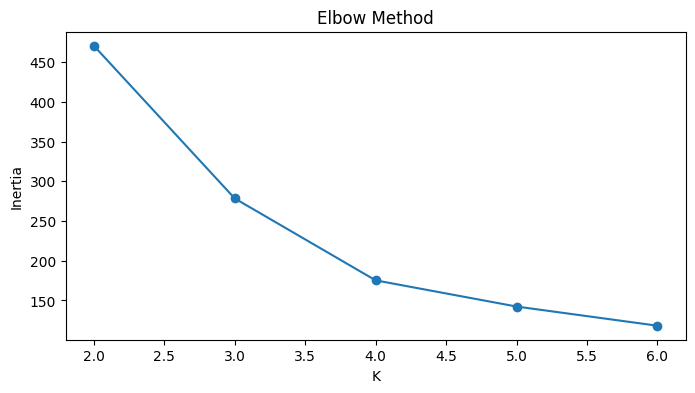

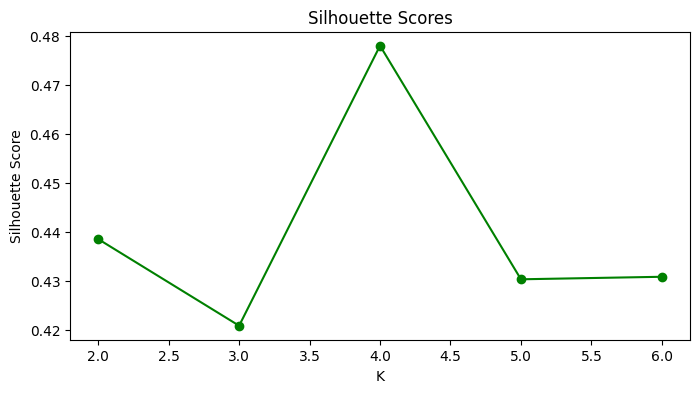

[(2, 0.4385659311817898),
 (3, 0.42088089479073354),
 (4, 0.4780487701721596),
 (5, 0.4303603492902937),
 (6, 0.4308747656188979)]

In [4]:
inertias = []
sil_scores = []
k_values = range(2, 7)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(list(k_values), inertias, marker='o', label='Inertia')
ax1.set_xlabel('K')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
plt.show()

fig, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(list(k_values), sil_scores, marker='o', color='green', label='Silhouette')
ax2.set_xlabel('K')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Scores')
plt.show()

list(zip(k_values, sil_scores))

## 3) Fit K-Means and Label Clusters
Set K based on the plots above (default: 3).

In [5]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_work['cluster'] = kmeans.fit_predict(X)

df_work['cluster'].value_counts().sort_index()

cluster
0    17
1    11
2    22
Name: count, dtype: int64

## 4) Interpret Clusters
Use cluster-level means to classify groups as at-risk, high performers, or career-confused.

In [7]:
numeric_cols = df_work.select_dtypes(include=[np.number]).columns.tolist()

cluster_means = df_work.groupby('cluster')[numeric_cols].mean().round(2)
cluster_means

,age,semester,gpa,attendance,assignments_completion,stress_level,sleep_hours,mental_wellbeing,productivity_score,distractions,career_clarity,skill_readiness,engagement_score,APS,WWS,PTMS,CRS,SRI,cluster
cluster,,,,,,,,,,,,,,,,,,,
0,22.06,6.71,8.81,93.06,95.35,3.59,7.24,8.24,8.24,2.76,6.53,7.41,69.59,91.13,81.49,76.76,69.67,81.32,0.0
1,20.91,4.82,6.30,76.18,74.91,8.09,4.18,3.91,3.91,8.00,2.91,3.91,65.64,69.27,35.09,45.49,43.55,51.35,1.0
2,21.23,3.86,7.51,86.32,88.00,5.86,5.95,6.14,6.14,4.86,4.86,5.77,85.68,81.12,62.06,70.02,62.93,70.90,2.0


In [8]:
# Heuristic labeling based on relative performance and career clarity
gpa_low, gpa_high = df['gpa'].quantile([0.33, 0.66])
att_low, att_high = df['attendance'].quantile([0.33, 0.66])
prod_low, prod_high = df['productivity_score'].quantile([0.33, 0.66])
stress_high = df['stress_level'].quantile(0.66)
career_low = df['career_clarity'].quantile(0.33)
skill_low = df['skill_readiness'].quantile(0.33)
mental_low = df['mental_wellbeing'].quantile(0.33)

def label_cluster(row):
    if (row['gpa'] <= gpa_low or row['attendance'] <= att_low or row['mental_wellbeing'] <= mental_low) and row['stress_level'] >= stress_high:
        return 'At-risk'
    if row['gpa'] >= gpa_high and row['attendance'] >= att_high and row['productivity_score'] >= prod_high and row['stress_level'] < stress_high:
        return 'High performer'
    if row['career_clarity'] <= career_low or row['skill_readiness'] <= skill_low:
        return 'Career-confused'
    return 'Stable'

cluster_labels = cluster_means.apply(label_cluster, axis=1)
cluster_labels

cluster
0     High performer
1            At-risk
2    Career-confused
dtype: str

In [9]:
df_work['cluster_type'] = df_work['cluster'].map(cluster_labels)
df_work[['student_id', 'cluster', 'cluster_type']].head()

,student_id,cluster,cluster_type
0,S001,0,High performer
1,S002,1,At-risk
2,S003,0,High performer
3,S004,1,At-risk
4,S005,0,High performer


## 5) Compare ML Clusters vs Rule-Based SRI
Compare cluster types with SRI-based risk bands and original Category.

In [10]:
df_work['sri_band'] = pd.qcut(df_work['SRI'], q=3, labels=['At-risk', 'Moderate', 'High performer'])

crosstab_cluster_sri = pd.crosstab(df_work['cluster_type'], df_work['sri_band'])
crosstab_cluster_cat = pd.crosstab(df_work['cluster_type'], df_work['Category'])

crosstab_cluster_sri, crosstab_cluster_cat

(sri_band         At-risk  Moderate  High performer
 cluster_type                                      
 At-risk               11         0               0
 Career-confused        6        14               2
 High performer         0         2              15,
 Category         Blue  Green  Red  Yellow
 cluster_type                             
 At-risk             0      0   10       1
 Career-confused     6      0    0      16
 High performer     14      3    0       0)

## 6) Visualize Clusters
PCA reduces features to 2D for plotting.

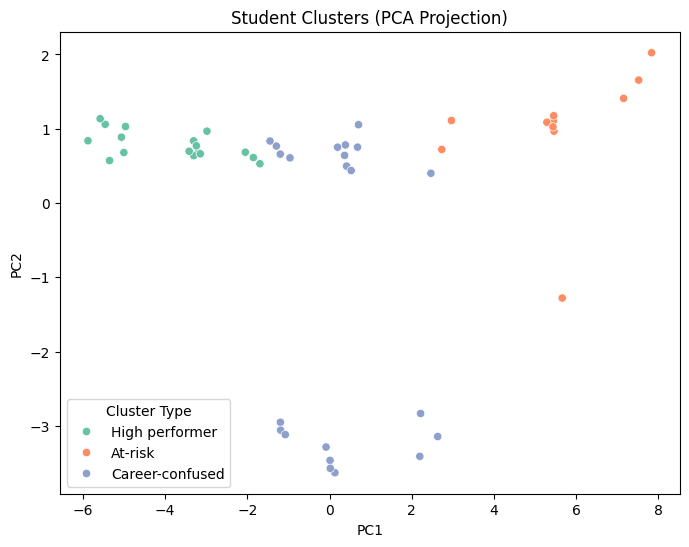

In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plot_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
plot_df['cluster_type'] = df_work['cluster_type'].values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='cluster_type', palette='Set2')
plt.title('Student Clusters (PCA Projection)')
plt.legend(title='Cluster Type')
plt.show()

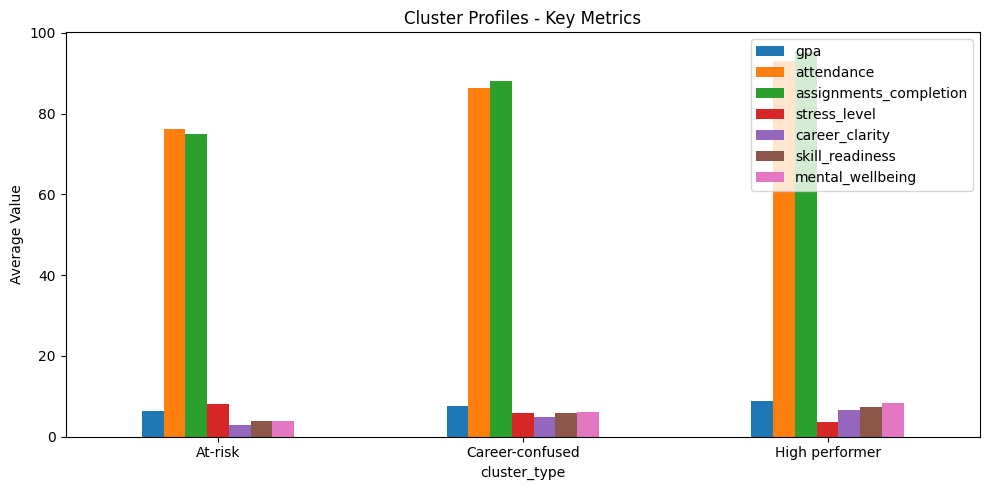

In [12]:
# Cluster profile for key metrics
key_metrics = ['gpa','attendance','assignments_completion','stress_level','career_clarity','skill_readiness','mental_wellbeing']

profile_df = df_work.groupby('cluster_type')[key_metrics].mean().round(2)
profile_df.plot(kind='bar', figsize=(10, 5))
plt.title('Cluster Profiles - Key Metrics')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
from matplotlib.backends.backend_pdf import PdfPages
from datetime import date

def _paginate_lines(lines, max_lines=52):
    for i in range(0, len(lines), max_lines):
        yield lines[i:i + max_lines]

def _write_text_pdf(path, title, sections):
    lines = [title, "", f"Generated on: {date.today().isoformat()}", ""]
    for heading, body in sections:
        lines.append(heading)
        lines.extend(body.splitlines())
        lines.append("")
    with PdfPages(path) as pdf:
        for page_lines in _paginate_lines(lines):
            fig, ax = plt.subplots(figsize=(8.5, 11))
            ax.axis("off")
            ax.text(0.01, 0.99, "\n".join(page_lines), va="top", ha="left", family="monospace", fontsize=10)
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

# Build interpretation content
cluster_counts = df_work['cluster_type'].value_counts()
cluster_summary = df_work.groupby('cluster_type')[
    key_metrics + ['SRI','APS','WWS','PTMS','CRS']
].mean().round(2)

interp_sections = [
    ("Cluster counts", cluster_counts.to_string()),
    ("Cluster label mapping (cluster -> type)", cluster_labels.to_string()),
    ("Key metric means by cluster type", cluster_summary.to_string()),
    ("SRI band vs cluster type", crosstab_cluster_sri.to_string()),
    ("Original Category vs cluster type", crosstab_cluster_cat.to_string()),
]

_write_text_pdf("Cluster_Interpretation.pdf", "Cluster Interpretation", interp_sections)

# Build recommendations content
def _recommendations_for(cluster_type, row):
    if cluster_type == "At-risk":
        return [
            "- Prioritize attendance and study plan with weekly targets.",
            "- Assign a mentor and schedule counseling/check-ins.",
            "- Provide tutoring and time-management support.",
            "- Reduce stressors with wellbeing workshops.",
        ]
    if cluster_type == "High performer":
        return [
            "- Offer advanced projects, honors tracks, or research roles.",
            "- Provide leadership or peer-mentoring opportunities.",
            "- Connect to internships and competitive programs.",
            "- Keep monitoring workload to avoid burnout.",
        ]
    if cluster_type == "Career-confused":
        return [
            "- Run career counseling and skill mapping sessions.",
            "- Offer short-term skill bootcamps and portfolio reviews.",
            "- Facilitate industry talks and shadowing opportunities.",
            "- Pair with alumni or career mentors for guidance.",
        ]
    return [
        "- Maintain current study habits and engagement.",
        "- Provide periodic check-ins and goal refresh.",
        "- Encourage skill growth through electives or workshops.",
    ]

rec_sections = []
for cluster_type, row in cluster_summary.iterrows():
    n = int(cluster_counts.get(cluster_type, 0))
    key_avg = row[key_metrics].round(2).to_string()
    recs = "\n".join(_recommendations_for(cluster_type, row))
    body = "Key averages:\n" + key_avg + "\n\nRecommendations:\n" + recs
    rec_sections.append((f"{cluster_type} (n={n})", body))

_write_text_pdf("Cluster_Recommendations.pdf", "Cluster Recommendations", rec_sections)

print("Generated PDFs: Cluster_Interpretation.pdf, Cluster_Recommendations.pdf")

Generated PDFs: Cluster_Interpretation.pdf, Cluster_Recommendations.pdf
